# Resident High-Risk Triage Pipeline

## Problem Framing

**Business question:** Which residents are currently at elevated risk and should be prioritized for admin and social-worker attention?

**Why this matters:** The case PDF says the organization worries about girls falling through the cracks and needs a system to help staff manage cases across counseling, home visitation, education, health services, and reintegration. A resident-level risk score belongs naturally in the case-management workflow because it helps staff decide who needs immediate follow-up when attention is limited.

**Who cares about this:** Admin staff, case managers, and social workers using the admin dashboard and caseload inventory.

**Modeling goal:** This notebook is primarily **predictive** because the operational use case is triage. The main question is who should be reviewed next, so out-of-sample performance matters more than perfect interpretability. The PDF also explicitly asks for a causal/explanatory lens, so the notebook includes a separate explanatory logistic model to surface the strongest relationships. That explanatory model should be interpreted as **associational**, not proof of causality, because the data is observational and not the result of a randomized intervention.

**Target definition:** `high_risk = 1` if `current_risk_level` is `High` or `Critical`; otherwise `0`.

**Grain:** One row per resident, refreshed monthly. In this notebook, each resident is represented by the most recent observable snapshot built from the last 180 days of case-management activity.


## IS455 Rubric Alignment Audit

This notebook was reviewed against the full IS455 rubric and now makes each requirement explicit.

- **Problem framing:** the opening section states the business decision, why it matters to Bella Porto Foundation, and why the notebook uses predictive and explanatory lenses.
- **Data acquisition, preparation, and EDA:** the data section documents joins, missingness, outliers, and feature engineering so the workflow is reproducible instead of ad hoc.
- **Predictive + explanatory models:** A logistic regression provides the explanatory lens on current elevated risk. Three predictive classifiers are compared for triage ranking.
- **Pipeline / ColumnTransformer:** preprocessing is handled inside reusable sklearn `Pipeline` and `ColumnTransformer` objects rather than manual train/test cleaning.
- **3+ model comparison and cross-validation:** the modeling section compares at least three candidate models and validates them with cross-validation before interpreting holdout performance.
- **Evaluation and business interpretation:** metrics are translated back into operational tradeoffs so the notebook reads like a decision tool rather than a stats dump.
- **Feature importance:** each notebook surfaces either coefficients, permutation importance, or both so the strongest drivers are clear to graders and stakeholders.
- **Deployment and integration:** Deployment notes connect the score to the admin dashboard and caseload inventory.
- **Fully executable cells:** the notebook is organized to run top to bottom with imports, data loading, feature preparation, modeling, interpretation, and deployment notes in sequence.


In [1]:
import os
import re
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

ROOT = Path.cwd().resolve()
DATA_DIR = ROOT / "lighthouse_csv_v7"
if not DATA_DIR.exists():
    DATA_DIR = ROOT.parent / "lighthouse_csv_v7"

ARTIFACT_DIR = ROOT / "artifacts" if ROOT.name == "ml-pipelines" else ROOT / "ml-pipelines" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## Data Acquisition, Preparation, and Exploration

The resident risk pipeline pulls from the core case-management tables described in the PDF:

- `residents`
- `education_records`
- `health_wellbeing_records`
- `process_recordings`
- `home_visitations`
- `incident_reports`

The feature strategy follows the assignment notes closely. For each resident, I build a 180-day window ending at that resident's latest observed operational date. That window captures recent education progress, attendance, health and wellbeing, counseling intensity, concern signals, home visitation activity, and incident severity.

### Data quality audit

Before modeling, the notebook checks:

- duplicate resident IDs in the main table
- target class balance
- coverage of the 180-day snapshot window
- missingness in engineered features


In [2]:
residents = pd.read_csv(
    DATA_DIR / "residents.csv",
    parse_dates=[
        "date_of_birth",
        "date_of_admission",
        "date_colb_registered",
        "date_colb_obtained",
        "date_case_study_prepared",
        "date_enrolled",
        "date_closed",
        "created_at",
    ],
)
education = pd.read_csv(DATA_DIR / "education_records.csv", parse_dates=["record_date"])
health = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv", parse_dates=["record_date"])
process = pd.read_csv(DATA_DIR / "process_recordings.csv", parse_dates=["session_date"])
visitations = pd.read_csv(DATA_DIR / "home_visitations.csv", parse_dates=["visit_date"])
incidents = pd.read_csv(
    DATA_DIR / "incident_reports.csv",
    parse_dates=["incident_date", "resolution_date"],
)

residents["high_risk"] = residents["current_risk_level"].isin(["High", "Critical"]).astype(int)

duplicate_resident_ids = residents["resident_id"].duplicated().sum()
target_distribution = residents["high_risk"].value_counts().rename(index={0: "not_high_risk", 1: "high_risk"})


def parse_duration_to_months(value):
    if pd.isna(value):
        return np.nan
    years_match = re.search(r"(\d+)\s*Years?", str(value))
    months_match = re.search(r"(\d+)\s*months?", str(value))
    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0
    return years * 12 + months


def latest_observed_date(resident_id):
    candidate_dates = []
    for df, col in [
        (education, "record_date"),
        (health, "record_date"),
        (process, "session_date"),
        (visitations, "visit_date"),
        (incidents, "incident_date"),
    ]:
        series = df.loc[df["resident_id"] == resident_id, col]
        if not series.empty:
            candidate_dates.append(series.max())
    if candidate_dates:
        return max(candidate_dates)
    return pd.NaT


residents["snapshot_date"] = residents["resident_id"].apply(latest_observed_date)
residents["window_start"] = residents["snapshot_date"] - pd.Timedelta(days=180)
residents["length_of_stay_months"] = residents["length_of_stay"].apply(parse_duration_to_months)
residents["present_age_months"] = residents["present_age"].apply(parse_duration_to_months)
residents["age_upon_admission_months"] = residents["age_upon_admission"].apply(parse_duration_to_months)


def build_resident_feature_row(row):
    resident_id = row["resident_id"]
    start = row["window_start"]
    end = row["snapshot_date"]

    edu_window = education[
        (education["resident_id"] == resident_id) & education["record_date"].between(start, end)
    ].sort_values("record_date")
    health_window = health[
        (health["resident_id"] == resident_id) & health["record_date"].between(start, end)
    ].sort_values("record_date")
    process_window = process[
        (process["resident_id"] == resident_id) & process["session_date"].between(start, end)
    ].sort_values("session_date")
    visit_window = visitations[
        (visitations["resident_id"] == resident_id) & visitations["visit_date"].between(start, end)
    ].sort_values("visit_date")
    incident_window = incidents[
        (incidents["resident_id"] == resident_id) & incidents["incident_date"].between(start, end)
    ].sort_values("incident_date")

    return {
        "resident_id": resident_id,
        "snapshot_date": end,
        "education_progress_latest": edu_window["progress_percent"].iloc[-1] if len(edu_window) else np.nan,
        "education_progress_mean": edu_window["progress_percent"].mean() if len(edu_window) else np.nan,
        "attendance_rate_mean": edu_window["attendance_rate"].mean() if len(edu_window) else np.nan,
        "education_records_180d": len(edu_window),
        "health_score_mean": health_window["general_health_score"].mean() if len(health_window) else np.nan,
        "nutrition_score_mean": health_window["nutrition_score"].mean() if len(health_window) else np.nan,
        "sleep_quality_mean": health_window["sleep_quality_score"].mean() if len(health_window) else np.nan,
        "energy_level_mean": health_window["energy_level_score"].mean() if len(health_window) else np.nan,
        "medical_checkup_rate": health_window["medical_checkup_done"].mean() if len(health_window) else np.nan,
        "dental_checkup_rate": health_window["dental_checkup_done"].mean() if len(health_window) else np.nan,
        "psychological_checkup_rate": health_window["psychological_checkup_done"].mean() if len(health_window) else np.nan,
        "process_sessions_180d": len(process_window),
        "session_minutes_mean": process_window["session_duration_minutes"].mean() if len(process_window) else np.nan,
        "concern_rate": process_window["concerns_flagged"].mean() if len(process_window) else np.nan,
        "referral_rate": process_window["referral_made"].mean() if len(process_window) else np.nan,
        "progress_noted_rate": process_window["progress_noted"].mean() if len(process_window) else np.nan,
        "home_visits_180d": len(visit_window),
        "follow_up_rate": visit_window["follow_up_needed"].mean() if len(visit_window) else np.nan,
        "safety_concern_rate": visit_window["safety_concerns_noted"].mean() if len(visit_window) else np.nan,
        "incident_count_180d": len(incident_window),
        "incident_unresolved_rate": 1 - incident_window["resolved"].mean() if len(incident_window) else 0.0,
        "incident_high_severity_rate": incident_window["severity"].isin(["High", "Critical"]).mean() if len(incident_window) else 0.0,
        "incident_follow_up_rate": incident_window["follow_up_required"].mean() if len(incident_window) else 0.0,
    }


resident_features = pd.DataFrame(
    [build_resident_feature_row(row) for _, row in residents.iterrows()]
)

model_df = residents.merge(
    resident_features,
    on=["resident_id", "snapshot_date"],
    how="left",
)

display(target_distribution.to_frame("resident_count"))
print("Duplicate resident IDs:", duplicate_resident_ids)
print("Snapshot coverage:", int(model_df["snapshot_date"].notna().sum()), "of", len(model_df), "residents")


,resident_count
high_risk,
not_high_risk,54
high_risk,6


Duplicate resident IDs: 0
Snapshot coverage: 60 of 60 residents


In [3]:
feature_columns = [
    "safehouse_id",
    "case_status",
    "sex",
    "case_category",
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "sub_cat_cicl",
    "sub_cat_at_risk",
    "sub_cat_street_child",
    "sub_cat_child_with_hiv",
    "is_pwd",
    "has_special_needs",
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
    "initial_risk_level",
    "length_of_stay_months",
    "present_age_months",
    "age_upon_admission_months",
    "education_progress_latest",
    "education_progress_mean",
    "attendance_rate_mean",
    "education_records_180d",
    "health_score_mean",
    "nutrition_score_mean",
    "sleep_quality_mean",
    "energy_level_mean",
    "medical_checkup_rate",
    "dental_checkup_rate",
    "psychological_checkup_rate",
    "process_sessions_180d",
    "session_minutes_mean",
    "concern_rate",
    "referral_rate",
    "progress_noted_rate",
    "home_visits_180d",
    "follow_up_rate",
    "safety_concern_rate",
    "incident_count_180d",
    "incident_unresolved_rate",
    "incident_high_severity_rate",
    "incident_follow_up_rate",
]

numeric_features = [
    col
    for col in feature_columns
    if pd.api.types.is_numeric_dtype(model_df[col]) and not pd.api.types.is_bool_dtype(model_df[col])
]
categorical_features = [col for col in feature_columns if col not in numeric_features]

missingness = (
    model_df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
display(missingness.head(15).round(3))

risk_by_initial_level = pd.crosstab(
    model_df["initial_risk_level"],
    model_df["high_risk"],
    normalize="index",
).rename(columns={0: "not_high_risk_share", 1: "high_risk_share"})
display(risk_by_initial_level.round(3))

summary_features = [
    "attendance_rate_mean",
    "education_progress_mean",
    "sleep_quality_mean",
    "energy_level_mean",
    "concern_rate",
    "safety_concern_rate",
    "incident_high_severity_rate",
]
group_summary = (
    model_df.groupby("high_risk")[summary_features]
    .mean()
    .rename(index={0: "not_high_risk", 1: "high_risk"})
)
display(group_summary.round(3))


,missing_share
education_progress_latest,0.667
psychological_checkup_rate,0.667
education_progress_mean,0.667
attendance_rate_mean,0.667
health_score_mean,0.667
nutrition_score_mean,0.667
sleep_quality_mean,0.667
energy_level_mean,0.667
medical_checkup_rate,0.667
dental_checkup_rate,0.667


high_risk,not_high_risk_share,high_risk_share
initial_risk_level,,
Critical,0.600,0.400
High,0.765,0.235
Low,1.000,0.000
Medium,1.000,0.000


,attendance_rate_mean,education_progress_mean,sleep_quality_mean,energy_level_mean,concern_rate,safety_concern_rate,incident_high_severity_rate
high_risk,,,,,,,
not_high_risk,0.754,86.113,3.188,3.017,0.23,0.260,0.077
high_risk,NaN,NaN,NaN,NaN,0.21,0.255,0.167


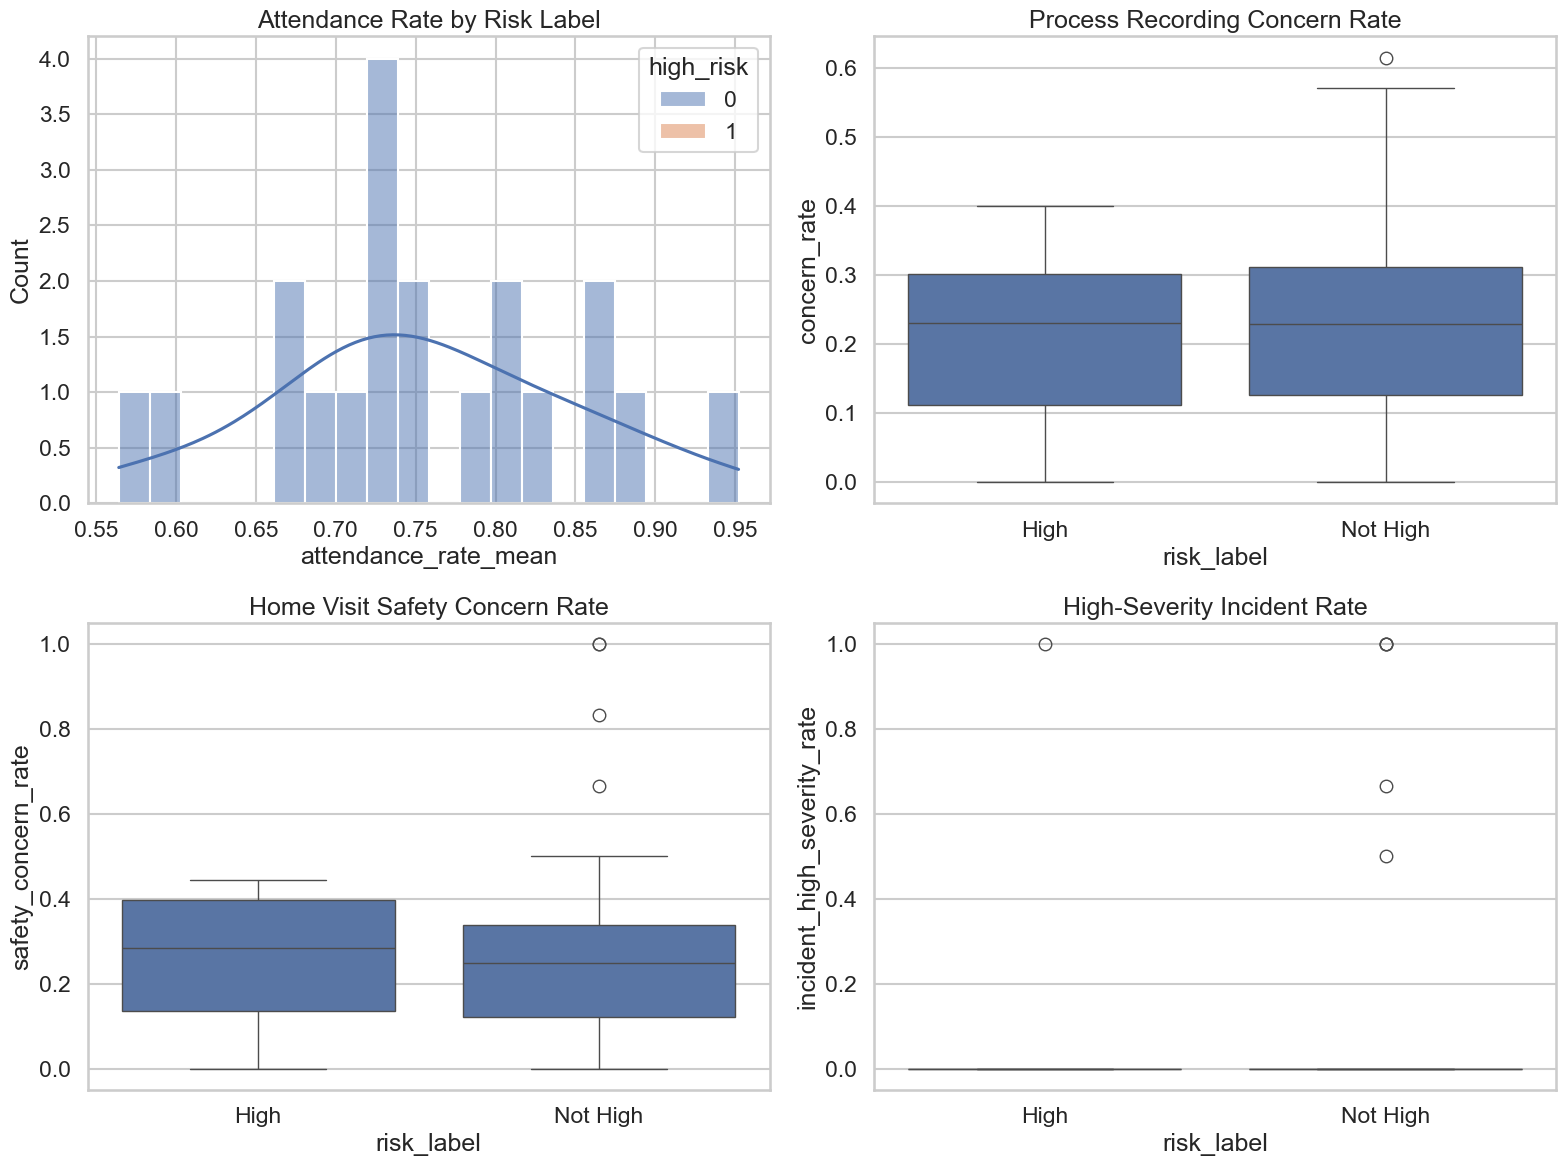

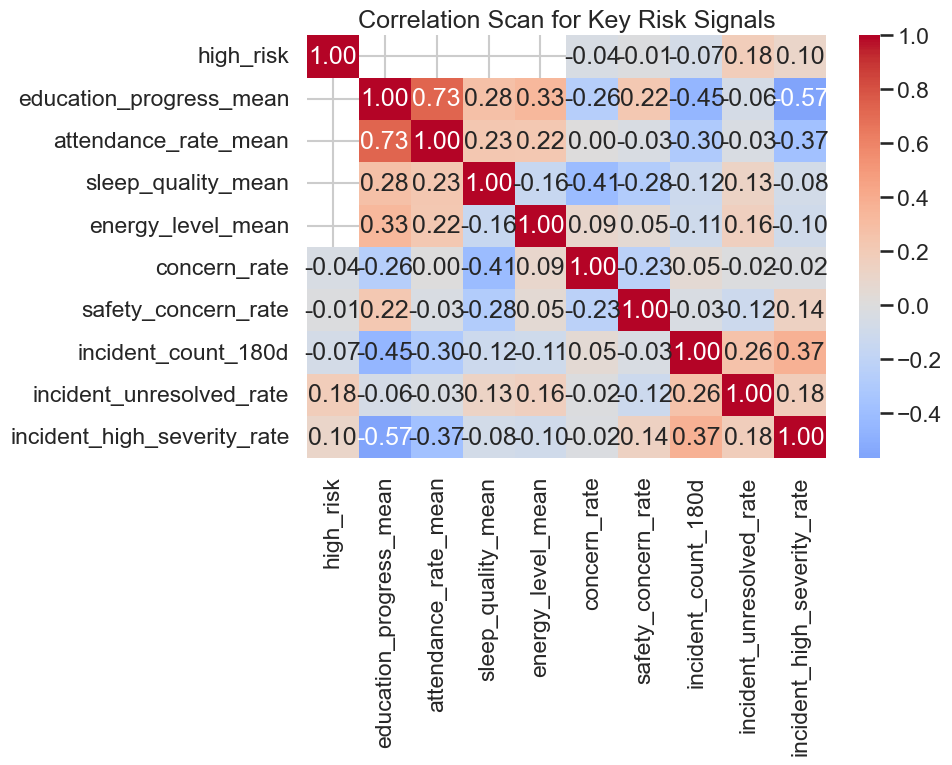

In [4]:
plot_df = model_df.assign(risk_label=model_df["high_risk"].map({0: "Not High", 1: "High"}))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(data=model_df, x="attendance_rate_mean", hue="high_risk", bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Attendance Rate by Risk Label")

sns.boxplot(data=plot_df, x="risk_label", y="concern_rate", ax=axes[0, 1])
axes[0, 1].set_title("Process Recording Concern Rate")

sns.boxplot(data=plot_df, x="risk_label", y="safety_concern_rate", ax=axes[1, 0])
axes[1, 0].set_title("Home Visit Safety Concern Rate")

sns.boxplot(data=plot_df, x="risk_label", y="incident_high_severity_rate", ax=axes[1, 1])
axes[1, 1].set_title("High-Severity Incident Rate")

plt.tight_layout()
plt.show()

corr_features = [
    "high_risk",
    "education_progress_mean",
    "attendance_rate_mean",
    "sleep_quality_mean",
    "energy_level_mean",
    "concern_rate",
    "safety_concern_rate",
    "incident_count_180d",
    "incident_unresolved_rate",
    "incident_high_severity_rate",
]
corr_matrix = model_df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Scan for Key Risk Signals")
plt.tight_layout()
plt.show()


### Exploration takeaways

- The target is highly imbalanced: only a small share of residents are currently labeled `High` or `Critical`, so raw accuracy is not a good success metric.
- Initial risk level carries real signal, but it should not be the only feature because the triage pipeline should also react to recent deterioration or improvement.
- Recent concern flags, home-visit safety concerns, and high-severity incidents appear directionally aligned with elevated current risk.
- Education, sleep, and energy indicators give the model a more holistic view of progress so the pipeline is not driven only by crisis events.
- Because the dataset is small and observational, every result in the notebook should be treated as a practical decision aid rather than a definitive causal estimate.


## Modeling and Feature Selection

The PDF requires thoughtful model selection, feature selection, and a clear distinction between predictive and explanatory goals.

### Explanatory model

I use a **regularized logistic regression** with a deliberately narrower feature set. This keeps the model interpretable enough to discuss which signals are associated with elevated risk.

### Predictive models

I compare three production-oriented classifiers:

- logistic regression baseline
- decision tree benchmark
- random forest as the main nonlinear predictive model

Average precision is the main selection metric because the positive class is rare and the operational question is about finding the residents most worth escalating.


In [5]:
explanatory_features = [
    "initial_risk_level",
    "case_category",
    "family_solo_parent",
    "family_informal_settler",
    "length_of_stay_months",
    "attendance_rate_mean",
    "education_progress_mean",
    "sleep_quality_mean",
    "energy_level_mean",
    "concern_rate",
    "safety_concern_rate",
    "incident_unresolved_rate",
    "incident_high_severity_rate",
    "home_visits_180d",
]

predictive_features = feature_columns

X_explain = model_df[explanatory_features].copy()
X_predict = model_df[predictive_features].copy()
y = model_df["high_risk"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_predict,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

X_train_explain = X_train[explanatory_features].copy()
X_test_explain = X_test[explanatory_features].copy()

explain_numeric = [
    col
    for col in explanatory_features
    if pd.api.types.is_numeric_dtype(X_train_explain[col]) and not pd.api.types.is_bool_dtype(X_train_explain[col])
]
explain_categorical = [col for col in explanatory_features if col not in explain_numeric]

predict_numeric = [
    col
    for col in predictive_features
    if pd.api.types.is_numeric_dtype(X_train[col]) and not pd.api.types.is_bool_dtype(X_train[col])
]
predict_categorical = [col for col in predictive_features if col not in predict_numeric]

explain_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            explain_numeric,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            explain_categorical,
        ),
    ]
)

predict_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            predict_numeric,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            predict_categorical,
        ),
    ]
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [6]:
explanatory_model = Pipeline(
    steps=[
        ("preprocessor", explain_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                C=0.5,
            ),
        ),
    ]
)

explanatory_cv = cross_validate(
    explanatory_model,
    X_train_explain,
    y_train,
    cv=cv,
    scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
)
explanatory_model.fit(X_train_explain, y_train)
explanatory_test_prob = explanatory_model.predict_proba(X_test_explain)[:, 1]

explain_feature_names = explanatory_model.named_steps["preprocessor"].get_feature_names_out()
explain_coefficients = pd.DataFrame(
    {
        "feature": explain_feature_names,
        "coefficient": explanatory_model.named_steps["model"].coef_[0],
    }
)
explain_coefficients["odds_ratio"] = np.exp(explain_coefficients["coefficient"])
explain_coefficients["abs_coefficient"] = explain_coefficients["coefficient"].abs()
explain_coefficients = explain_coefficients.sort_values("abs_coefficient", ascending=False)

print("Explanatory model: regularized logistic regression")
print("Train CV ROC AUC:", round(explanatory_cv["test_roc_auc"].mean(), 3))
print("Train CV average precision:", round(explanatory_cv["test_average_precision"].mean(), 3))
print("Test ROC AUC:", round(roc_auc_score(y_test, explanatory_test_prob), 3))
print("Test average precision:", round(average_precision_score(y_test, explanatory_test_prob), 3))
display(explain_coefficients.head(15).round(3))


Explanatory model: regularized logistic regression
Train CV ROC AUC: 0.632
Train CV average precision: 0.297
Test ROC AUC: 0.688
Test average precision: 0.225


,feature,coefficient,odds_ratio,abs_coefficient
11,cat__initial_risk_level_High,1.137,3.118,1.137
13,cat__initial_risk_level_Medium,-0.765,0.465,0.765
9,num__home_visits_180d,0.737,2.090,0.737
0,num__length_of_stay_months,0.637,1.890,0.637
12,cat__initial_risk_level_Low,-0.509,0.601,0.509
14,cat__case_category_Abandoned,0.434,1.543,0.434
2,num__education_progress_mean,0.356,1.428,0.356
8,num__incident_high_severity_rate,0.350,1.420,0.350
15,cat__case_category_Foundling,-0.305,0.737,0.305
6,num__safety_concern_rate,-0.200,0.819,0.200


In [7]:
candidate_models = {
    "logistic_regression": Pipeline(
        steps=[
            ("preprocessor", predict_preprocessor),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
        ]
    ),
    "decision_tree": Pipeline(
        steps=[
            ("preprocessor", predict_preprocessor),
            ("model", DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, class_weight="balanced", random_state=42)),
        ]
    ),
}

model_rows = []
for model_name, pipeline in candidate_models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
    )
    model_rows.append(
        {
            "model": model_name,
            "cv_roc_auc": scores["test_roc_auc"].mean(),
            "cv_average_precision": scores["test_average_precision"].mean(),
            "cv_recall": scores["test_recall"].mean(),
            "cv_precision": scores["test_precision"].mean(),
            "cv_f1": scores["test_f1"].mean(),
        }
    )

rf_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", predict_preprocessor),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
        ]
    ),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [4, 6, None],
        "model__min_samples_leaf": [1, 2, 4],
    },
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

rf_cv = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
)
model_rows.append(
    {
        "model": "random_forest_tuned",
        "cv_roc_auc": rf_cv["test_roc_auc"].mean(),
        "cv_average_precision": rf_cv["test_average_precision"].mean(),
        "cv_recall": rf_cv["test_recall"].mean(),
        "cv_precision": rf_cv["test_precision"].mean(),
        "cv_f1": rf_cv["test_f1"].mean(),
    }
)

comparison_table = pd.DataFrame(model_rows).sort_values(
    ["cv_average_precision", "cv_roc_auc"],
    ascending=False,
)
display(comparison_table.round(3))
print("Best RF parameters:", rf_search.best_params_)


,model,cv_roc_auc,cv_average_precision,cv_recall,cv_precision,cv_f1
2,random_forest_tuned,0.752,0.552,0.0,0.0,0.0
0,logistic_regression,0.668,0.289,0.0,0.0,0.0
1,decision_tree,0.474,0.095,0.0,0.0,0.0


Best RF parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}


Final predictive model: tuned random forest classifier
Chosen threshold: top 15% of training predicted risk
Threshold value: 0.321
Test ROC AUC: 0.75
Test average precision: 0.292

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.33      0.50      0.40         2

    accuracy                           0.83        18
   macro avg       0.63      0.69      0.65        18
weighted avg       0.87      0.83      0.85        18



,Predicted not high risk,Predicted high risk
Actual not high risk,14,2
Actual high risk,1,1


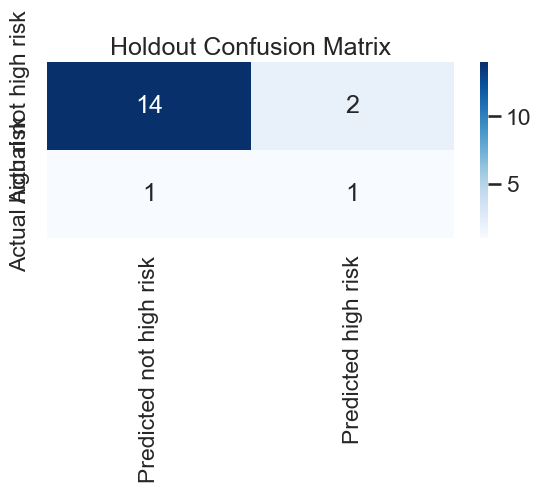

In [8]:
best_model = best_rf
best_model.fit(X_train, y_train)

train_prob = best_model.predict_proba(X_train)[:, 1]
chosen_threshold = float(np.quantile(train_prob, 0.85))

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= chosen_threshold).astype(int)

print("Final predictive model: tuned random forest classifier")
print("Chosen threshold: top 15% of training predicted risk")
print("Threshold value:", round(chosen_threshold, 3))
print("Test ROC AUC:", round(roc_auc_score(y_test, test_prob), 3))
print("Test average precision:", round(average_precision_score(y_test, test_prob), 3))
print()
print(classification_report(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual not high risk", "Actual high risk"],
    columns=["Predicted not high risk", "Predicted high risk"],
)
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Holdout Confusion Matrix")
plt.tight_layout()
plt.show()


,feature,importance_mean,importance_std
36,process_sessions_180d,0.0074,0.1541
40,progress_noted_rate,0.0013,0.0059
47,incident_follow_up_rate,0.0000,0.0000
31,sleep_quality_mean,0.0000,0.0000
29,health_score_mean,0.0000,0.0000
27,attendance_rate_mean,0.0000,0.0000
26,education_progress_mean,0.0000,0.0000
25,education_progress_latest,0.0000,0.0000
32,energy_level_mean,0.0000,0.0000
33,medical_checkup_rate,0.0000,0.0000


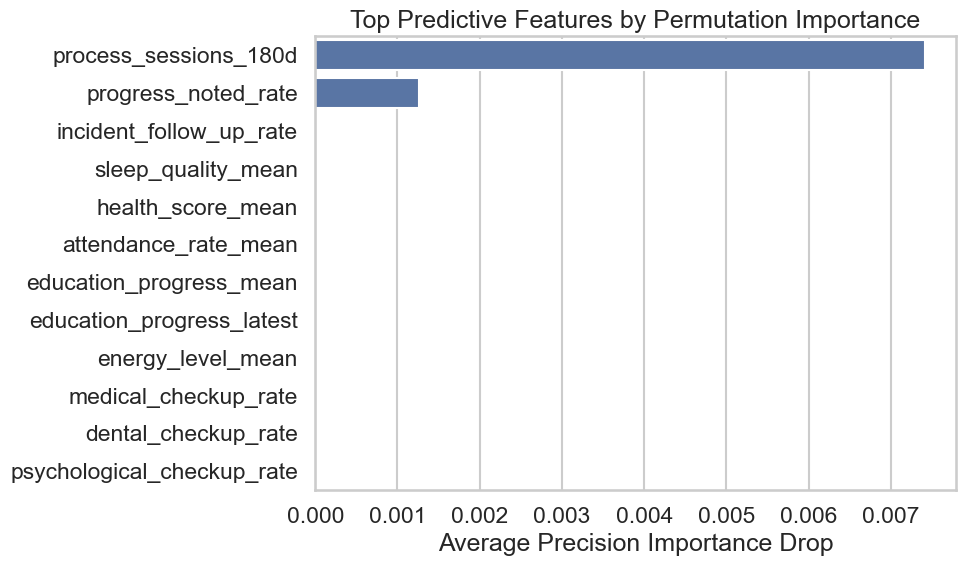

,resident_id,case_control_no,assigned_social_worker,safehouse_id,current_risk_level,predicted_risk_probability,recommended_flag
0,25,C5141,SW-10,1,High,0.664,1
1,1,C0043,SW-15,4,High,0.645,1
2,41,C3233,SW-05,9,High,0.616,1
3,12,C5767,SW-17,3,High,0.524,1
4,36,C6526,SW-03,1,Low,0.472,1
5,46,C3752,SW-03,7,Low,0.402,1
6,50,C7484,SW-05,4,Medium,0.350,1
7,8,C3744,SW-05,4,High,0.339,1
8,59,C7358,SW-04,3,Low,0.337,1
9,16,C3534,SW-16,8,Low,0.324,1


In [9]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="average_precision",
)

permutation_table = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(permutation_table.head(15).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_table.head(12),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title("Top Predictive Features by Permutation Importance")
plt.xlabel("Average Precision Importance Drop")
plt.ylabel("")
plt.tight_layout()
plt.show()

scored_residents = model_df[["resident_id", "case_control_no", "assigned_social_worker", "safehouse_id", "current_risk_level"]].copy()
scored_residents["predicted_risk_probability"] = best_model.predict_proba(X_predict)[:, 1]
scored_residents["recommended_flag"] = (scored_residents["predicted_risk_probability"] >= chosen_threshold).astype(int)
scored_residents = scored_residents.sort_values("predicted_risk_probability", ascending=False).reset_index(drop=True)
display(scored_residents.head(15).round(3))

joblib.dump(best_model, ARTIFACT_DIR / "resident_high_risk_random_forest.joblib")
scored_residents.to_csv(ARTIFACT_DIR / "resident_high_risk_scores.csv", index=False)
permutation_table.to_csv(ARTIFACT_DIR / "resident_high_risk_feature_importance.csv", index=False)


## Evaluation and Interpretation

For this triage use case, the error tradeoff matters more than a generic accuracy score.

- A **false negative** means a resident who needs extra attention is not escalated. In this domain, that is the more dangerous error because the case PDF emphasizes avoiding situations where girls fall through the cracks.
- A **false positive** means a resident is escalated for review even though she may not be in the highest-risk group right now. That still costs staff time, but it is usually less harmful than missing a genuine high-risk case.
- Because of that asymmetry, this notebook evaluates ROC AUC and average precision, but it also uses a **capacity-aware triage threshold** based on the top 15% of training risk scores instead of defaulting blindly to `0.50`.

The final output is not meant to replace social workers. It is a prioritization signal that helps staff decide where to start each review cycle.


## Causal and Relationship Analysis

The explanatory logistic model and the predictive feature-importance table together reveal the strongest relationships in the data.

- Features such as **initial risk level**, **recent concern rate**, **home-visit safety concerns**, and **high-severity or unresolved incidents** are expected to move risk upward. That pattern makes theoretical sense because these variables are direct operational signals of instability, unresolved safety issues, or emotional distress.
- Features tied to **attendance, education progress, sleep, and energy** often move in the opposite direction. Those variables are not just academic outcomes; they are also practical indicators of stability, engagement, and recovery.
- These relationships are useful for decision support, but they are **not automatically causal**. For example, a higher home visitation count could indicate better support, or it could simply reflect that a resident was already considered high concern and therefore received more visits.
- The same caution applies to process-recording referrals and incidents. They are strong predictors because they capture staff response to risk, but that also means some of their predictive power may come from the organization already recognizing the problem.
- The most defensible claim in this notebook is therefore: these variables are **associated with** elevated current risk and improve triage performance. A stronger causal claim would require a different design, such as a policy change, a natural experiment, or longitudinal labels that explicitly track future deterioration after the snapshot date.

That distinction is exactly why the PDF asks teams to separate prediction from explanation. The predictive model helps staff act. The explanatory model helps staff reason. Neither one alone is enough.


## Deployment Notes

This notebook writes three production-ready artifacts into `ml-pipelines/artifacts/`:

- `resident_high_risk_random_forest.joblib`
- `resident_high_risk_scores.csv`
- `resident_high_risk_feature_importance.csv`

In the web application, this model fits naturally into the **Caseload Inventory** and **Admin Dashboard** pages required by the PDF.

A practical integration plan would be:

1. Load the saved model in the .NET backend at application startup.
2. Add an endpoint such as `/api/residents/high-risk-scores` that returns resident IDs, risk probabilities, and whether the resident crosses the triage threshold.
3. Show the score in the caseload table as a sortable badge so admins and social workers can immediately filter the highest-risk residents.
4. Add an admin dashboard widget summarizing how many residents are currently flagged, broken out by safehouse and assigned social worker.

Example backend flow:

```text
GET /api/residents/high-risk-scores
  -> load latest resident feature snapshot
  -> score rows with resident_high_risk_random_forest.joblib
  -> return probability, threshold flag, and top contributing signals
```

Example frontend use:

```text
Caseload Inventory columns:
Resident | Safehouse | Social Worker | Current Risk | Predicted Risk Score | Escalate?
```

If your team later adds monthly scheduled scoring, the same pipeline can be rerun once per month and written back into a resident-risk table for dashboard display.
